In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

data_dir = "F:/crs/proj/2025_NOPP_comparison/helene_deltares_wave_model_output/helene89pervmax/"
nc_path = data_dir+"hurrywave_sp2.nc"
ds = xr.open_dataset(nc_path, mask_and_scale=True, decode_cf=True)
ds

<xarray.Dataset> Size: 85MB
Dimensions:           (stations: 425, sigma: 12, theta: 36, time: 115,
                       runtime: 1)
Coordinates:
  * sigma             (sigma) float32 48B 0.04 0.05032 0.06331 ... 0.3974 0.5
  * theta             (theta) float32 144B 5.0 15.0 25.0 ... 335.0 345.0 355.0
  * time              (time) datetime64[ns] 920B 2024-09-23 ... 2024-09-27T18...
Dimensions without coordinates: stations, runtime
Data variables:
    inp               int32 4B ...
    station_id        (stations) float32 2kB ...
    station_name      (stations) |S256 109kB ...
    station_x         (stations) float32 2kB ...
    station_y         (stations) float32 2kB ...
    crs               int32 4B ...
    point_spectrum2d  (time, stations, theta, sigma) float32 84MB ...
    total_runtime     (runtime) float32 4B ...
    average_dt        (runtime) float32 4B ...
Attributes:
    Conventions:                         Conventions = 'CF-1.6, SGRID-0.3
    Build-Revision-Date-Netcdf-library:  4.9.2 of Mar 14 2023 15:42:34 $
    Producer:                            HURRYWAVE
    Build-Revision:                      $Rev: xxx $
    Build-Date:                          $Date: 2024-06-18$
    title:                               HURRYWAVE 2D spectrum point output

In [2]:
# load bulk paramters from the .his file
hisfile = data_dir+"hurrywave_his.nc"
ds_his = xr.open_dataset(hisfile)
ds_his

<xarray.Dataset> Size: 7MB
Dimensions:         (stations: 435, time: 685, runtime: 1)
Coordinates:
  * time            (time) datetime64[ns] 5kB 2024-09-23 ... 2024-09-27T18:00:00
Dimensions without coordinates: stations, runtime
Data variables: (12/15)
    inp             int32 4B ...
    station_id      (stations) float32 2kB ...
    station_name    (stations) |S256 111kB ...
    station_x       (stations) float32 2kB ...
    station_y       (stations) float32 2kB ...
    station_z       (stations) float32 2kB ...
    ...              ...
    point_wavdir    (time, stations) float32 1MB ...
    point_dirspr    (time, stations) float32 1MB ...
    wind_speed      (time, stations) float32 1MB ...
    wind_direction  (time, stations) float32 1MB ...
    total_runtime   (runtime) float32 4B ...
    average_dt      (runtime) float32 4B ...
Attributes:
    Conventions:                         Conventions = 'CF-1.6, SGRID-0.3
    Build-Revision-Date-Netcdf-library:  4.9.2 of Mar 14 2023 15:42:34 $
    Producer:                            HurryWave
    Build-Revision:                      $Rev: xxx $
    Build-Date:                          $Date: 2024-06-18$
    title:                               HurryWave his point netcdf output

In [3]:
# calculate Hmo from HurryWave spectra

nc_path = data_dir+"hurrywave_sp2.nc"
ds = xr.open_dataset(nc_path, mask_and_scale=True, decode_cf=True)

S = ds['point_spectrum2d']   # (time, stations, theta, sigma)

time = ds['time'].values
f = ds['sigma'].values
theta_deg = ds['theta'].values

nT, nP, nD, nF = S.shape

Hmo = np.zeros((nT,nP))

for t in range(nT):
    for p in range(nP):
        Sfth = S.values[t,p,:,:]     # (theta,f)
        m0_f = np.trapezoid(Sfth, theta_deg, axis=0)
        m0 = np.trapezoid(m0_f, f)
        Hmo[t,p] = 4*np.sqrt(m0)


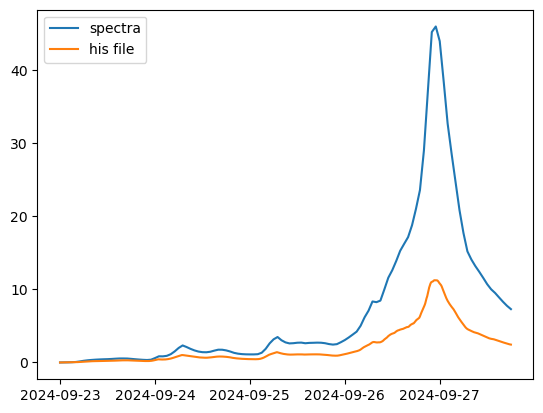

In [4]:
plt.plot( time, Hmo[:,300], label='spectra' )
plt.plot( ds_his['time'], ds_his['point_hm0'][:, 300], label='his file')
plt.legend()

In [5]:
print( 'shape of Hmo from spectra: ',np.shape( Hmo) )
print( 'shape of hm0 from .his file: ',np.shape( ds_his['point_hm0'] ) )
print( np.max (Hmo), np.max( ds_his['point_hm0']) )
print( np.max (Hmo) / np.max( ds_his['point_hm0']) )

shape of Hmo from spectra:  (115, 425)
shape of hm0 from .his file:  (685, 435)
50.915367126464844 <xarray.DataArray 'point_hm0' ()> Size: 4B
array(11.771618, dtype=float32)
<xarray.DataArray 'point_hm0' ()> Size: 8B
array(4.32526502)


In [6]:
# -----------------------------
# constants
# -----------------------------
g = 9.81
rho = 1025.

# -----------------------------
# load contour + normals
# -----------------------------
contour_file = 'contour30sp.csv'

df = pd.read_csv(contour_file)

normals_x = df['normals30_x'].values
normals_y = df['normals30_y'].values

contour_xy = np.column_stack((df['contour30s_x'], df['contour30s_y']))

# optional depth (set constant if needed)
h = 30.0

# -----------------------------
# open HurryWave spectra
# -----------------------------
nc_path = data_dir+"hurrywave_sp2.nc"
ds = xr.open_dataset(nc_path, mask_and_scale=True, decode_cf=True)

S = ds['point_spectrum2d']   # (time, stations, theta, sigma)

time = ds['time'].values
f = ds['sigma'].values
theta_deg = ds['theta'].values
theta_rad = np.deg2rad(theta_deg)

nT, nP, nD, nF = S.shape

# convert direction FROM -> TO
theta_to_deg = (theta_deg + 180.) % 360.
theta_to_rad = np.deg2rad(theta_to_deg)


# unit vectors for each direction bin
ux = np.sin(theta_to_rad)
uy = np.cos(theta_to_rad)

# -----------------------------
# dispersion → group velocity
# -----------------------------
omega = 2*np.pi*f

def solve_k(omega, h):
    k = omega**2/g
    for _ in range(20):
        kh = k*h
        t = np.tanh(kh)
        fval = g*k*t - omega**2
        df = g*t + g*k*(1-t**2)*h
        k = k - fval/df
    return k

k = solve_k(omega, h)

cp = omega/k
kh = k*h
cg = 0.5*cp*(1 + (2*kh)/np.sinh(2*kh))

# -----------------------------
# allocate outputs
# -----------------------------
Hs = np.zeros((nT,nP))
Tp = np.zeros((nT,nP))
Dir = np.zeros((nT,nP))

Fx = np.zeros((nT,nP))
Fy = np.zeros((nT,nP))
Fmag = np.zeros((nT,nP))
Fdir = np.zeros((nT,nP))
Fshore = np.zeros((nT,nP))

# -----------------------------
# main loop
# -----------------------------
for t in range(nT):

    for p in range(nP):

        Sfth = S.values[t,p,:,:]     # (theta,f)


        # ---- bulk stats ----

        m0_f = np.trapezoid(Sfth, theta_deg, axis=0)
        m0 = np.trapezoid(m0_f, f)

        Hs[t,p] = 4*np.sqrt(m0)

        ip = np.argmax(m0_f)
        Tp[t,p] = 1/f[ip]

        S_theta = np.trapezoid(Sfth, f, axis=1)

        th_rad = np.deg2rad(theta_to_deg)

        a1 = np.trapezoid(S_theta*np.cos(th_rad), theta_deg)
        b1 = np.trapezoid(S_theta*np.sin(th_rad), theta_deg)

        Dir[t,p] = (np.degrees(np.arctan2(b1,a1))+360)%360

        # ---- energy flux from spectrum ----

        Efth = rho*g*Sfth

        Fx_f = np.trapezoid(Efth*cg[None,:]*ux[:,None], theta_deg, axis=0)
        Fy_f = np.trapezoid(Efth*cg[None,:]*uy[:,None], theta_deg, axis=0)

        Fx[t,p] = np.trapezoid(Fx_f, f)
        Fy[t,p] = np.trapezoid(Fy_f, f)

        Fmag[t,p] = np.sqrt(Fx[t,p]**2 + Fy[t,p]**2)

        Fdir[t,p] = (np.degrees(np.arctan2(Fx[t,p],Fy[t,p]))+360)%360

        # ---- shoreward flux ----

        Fshore[t,p] = Fx[t,p]*normals_x[p] + Fy[t,p]*normals_y[p]

# -----------------------------
# convert to dataframe
# -----------------------------
df_out = pd.DataFrame({
    "time": np.repeat(time,nP),
    "station": np.tile(np.arange(nP),nT),
    "Hs": Hs.flatten(),
    "Tp": Tp.flatten(),
    "Dir": Dir.flatten(),
    "Fx": Fx.flatten(),
    "Fy": Fy.flatten(),
    "Fmag": Fmag.flatten(),
    "Fdir": Fdir.flatten(),
    "Fshore": Fshore.flatten()
})

df_out.head()

,time,station,Hs,Tp,Dir,Fx,Fy,Fmag,Fdir,Fshore
0,2024-09-23,0,0.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2024-09-23,1,0.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2024-09-23,2,0.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2024-09-23,3,0.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2024-09-23,4,0.0,25.0,0.0,0.0,0.0,0.0,0.0,0.0


In [7]:

S = ds["point_spectrum2d"].values  # (time, stations, theta, sigma)
f = ds["sigma"].values
theta_deg = ds["theta"].values
theta_rad = np.deg2rad(theta_deg)

# pick one spectrum slice
Sfth = S[20, 100, :, :]  # (theta, f)

m0_deg = np.trapezoid(np.trapezoid(Sfth, theta_deg, axis=0), f)   # integrate over degrees
m0_rad = np.trapezoid(np.trapezoid(Sfth, theta_rad, axis=0), f)   # integrate over radians

Hs_deg = 4*np.sqrt(m0_deg)
Hs_rad = 4*np.sqrt(m0_rad)

print("m0 (deg) =", m0_deg, "Hs (deg) =", Hs_deg)
print("m0 (rad) =", m0_rad, "Hs (rad) =", Hs_rad)
print("ratio m0_deg/m0_rad =", m0_deg/m0_rad)

m0 (deg) = 9.790537e-07 Hs (deg) = 0.003957886
m0 (rad) = 1.7087707e-08 Hs (rad) = 0.0005228798
ratio m0_deg/m0_rad = 57.295788


In [8]:
S = ds["point_spectrum2d"]

print("attrs:", S.attrs)
print("encoding:", {k: S.encoding.get(k) for k in ["dtype","scale_factor","add_offset","_FillValue"]})
print("raw dtype:", S.dtype)
print("min/max:", float(np.nanmin(S.values)), float(np.nanmax(S.values)))

attrs: {'units': '-', 'standard_name': 'spectrum_2d', 'long_name': 'Wave Spectrum (2D)'}
encoding: {'dtype': dtype('float32'), 'scale_factor': None, 'add_offset': None, '_FillValue': np.float32(-99999.0)}
raw dtype: float32
min/max: 0.0 155.0961456298828


In [9]:
print(ds["point_spectrum2d"].attrs)
print(ds["sigma"].attrs)
print(ds["theta"].attrs)
print({k: ds["point_spectrum2d"].encoding.get(k) for k in ["scale_factor","add_offset","dtype"]})
print("spec min/max:", float(ds["point_spectrum2d"].min()), float(ds["point_spectrum2d"].max()))

{'units': '-', 'standard_name': 'spectrum_2d', 'long_name': 'Wave Spectrum (2D)'}
{'units': 'Hz', 'standard_name': 'frequency', 'long_name': 'Wave spectrum frequency (Hz)'}
{'units': 'deg', 'standard_name': 'deg', 'long_name': 'Wave spectrum direction (deg, cartesian)'}
{'scale_factor': None, 'add_offset': None, 'dtype': dtype('float32')}
spec min/max: 0.0 155.0961456298828
